In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

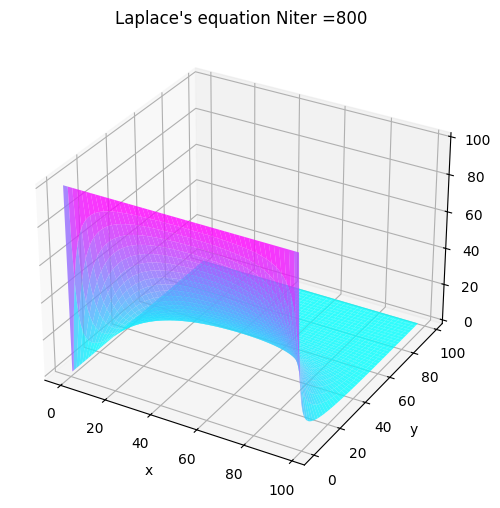

In [ ]:

#****** LaplaceLine.py in Paez, *************************************
#       Computational physics with python- Manuel Paez, Landau book.
#********************************************************************
Nmax, Niter, tol = 100, 800, 10**(-8)

V = np.zeros((Nmax, Nmax), float) # grid in 0V.

for k in range(0, Nmax):
  V[k,0] = 100.0 # let line at 100V

for iter in range(Niter): # iterations over algorithm. Niter times
  for i in range(1, Nmax-1):
    for j in range(1,Nmax-1):
      V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

#Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x
X, Y = np.meshgrid(x,y)

def functz(V,X,Y): # Function returns V(x, y)
  z = V[X,Y]
  return z

Z = functz(V,X,Y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)

ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

In [ ]:

#****** LaplaceLine.py in Paez, *************************************
#       Computational physics with python- Manuel Paez, Landau book.
#********************************************************************
def Laplace2D(V,Niter,x,y,tol):
  '''Int the V initial configutaration.\n Niter is the number of the itertions of the algorithm.
  x(y) the array in x(y) variable.
  Return X,Y,Z evolve Niter times using finite differences for the Laplace case.'''

  Nmax = V.shape[0]
  V = V_ini.copy()

  for iter in range(Niter): # iterations over algorithm. Niter times
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
    max_change = np.max(np.abs(V-V_ini))
    V = V_ini.copy()
    if max_change < tol:
      print('Converged after %d iterations'%iter)
      break
  X, Y = np.meshgrid(x,y)
  return X,Y,V, iter + 1



Iteraciones realizadas: 1000 (máx permitido: 1000)
Cambio máximo alcanzado: 0.022891133880705183


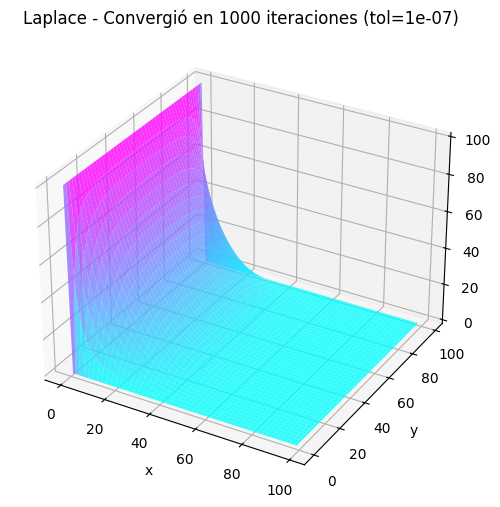

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
Nmax, Niter_max, tol = 100, 1000, 10**(-7)

# Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float)
V_ini[:, 0] = 100.0  # left line at 100V (más eficiente que el loop)

# Grid para graficar
x = np.arange(0, Nmax, 1)
y = x

# Función Laplace2D con criterio de convergencia basado en tol
def Laplace2D_convergence(V, max_iter, tol, x, y):
    V_new = V.copy()

    for iteration in range(max_iter):
        # Calcular nueva iteración
        for i in range(1, V.shape[0]-1):
            for j in range(1, V.shape[1]-1):
                V_new[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])

        # Calcular el cambio máximo (criterio de convergencia)
        max_change = np.max(np.abs(V_new - V))

        # Actualizar V
        V = V_new.copy()

        # Verificar convergencia
        if max_change < tol:
            print(f"Convergió después de {iteration + 1} iteraciones con tol={tol}")
            break

    X, Y = np.meshgrid(x, y)
    return X, Y, V, iteration + 1, max_change

# Ejecutar
X, Y, Z, iteraciones, max_change = Laplace2D_convergence(V_ini, Niter_max, tol, x, y)

print(f"Iteraciones realizadas: {iteraciones} (máx permitido: {Niter_max})")
print(f"Cambio máximo alcanzado: {max_change}")

# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title(f'Laplace - Convergió en {iteraciones} iteraciones (tol={tol})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

BIEN... No deberian ser tantos términos. son del orden de 100... CALCULAR EL ERROR RELATIVO~tol=10^-3

In [ ]:

#Define the n-esimo modo
def un(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100 #Voltage
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

Converged after 99 iterations
Max change: 8.526512829121202e-14


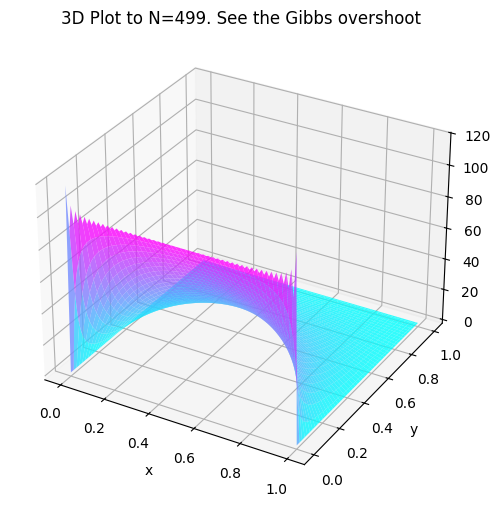

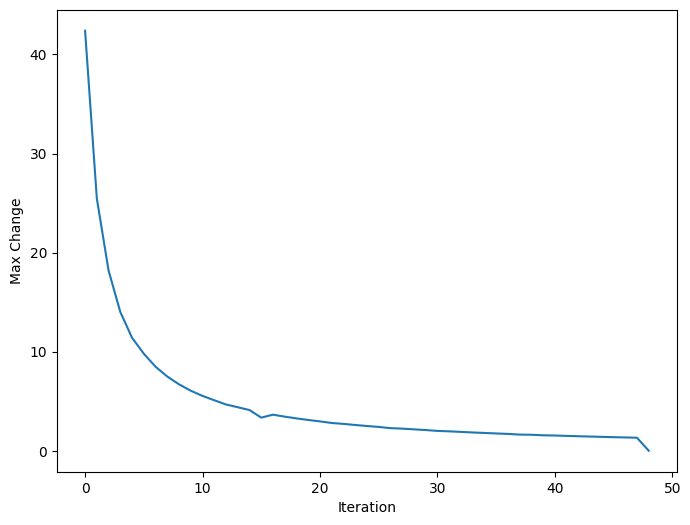

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the n-esimo modo
def un(x, y, n=1, L=1):
    'function to compute the n-esimo term of the Fourier serie'
    v0 = 100  # Voltage
    return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

# Making the grid to do the plot
tol = 10**(-3)
L = 1  # longitude
coordx = np.linspace(0, L, 100)  # 100 puntos
coordy = coordx
x, y = np.meshgrid(coordx, coordy, indexing='ij')
max_change_list = []
# Plot to N-1 frequencies
N = 500
z = np.zeros_like(x)  # Inicializar z con ceros del mismo tamaño que x
z_old = z.copy()  # Guardar copia para comparar

for n in range(1, N, 2):  # Only odd n values
    z += un(x, y, n, L)

    if n > 1:  # Verificar convergencia después de la primera iteración
        max_change = np.max(np.abs(z - z_old))
        max_change_list.append(max_change)
        if max_change < tol:
            print('Converged after %d iterations' % n)
            print('Max change:', max_change)
            break
        z_old = z.copy()  # Actualizar z_old para la siguiente iteración
    else:
        z_old = z.copy()  # Primera iteración: copiar z

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='cool', alpha=0.8)
ax.set_title('3D Plot to N=%d. See the Gibbs overshoot' % (N-1))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
fig = plt.figure(figsize=(8, 6))
plt.plot(range(len(max_change_list)), max_change_list)
plt.xlabel('Iteration')
plt.ylabel('Max Change')
plt.show()

BIEN...NO SON 50 TERMINOS. SON ALREDEDOR DE 11... ES POR LA FORMA QUE CALCULAS EL ERROR. NOTA: 4.7

In [ ]:
print(len(max_change_list))
max_change_list

49


[np.float64(42.39324653973988),
 np.float64(25.461585582239053),
 np.float64(18.18684684445647),
 np.float64(14.003108911439796),
 np.float64(11.399056137244756),
 np.float64(9.792917531630408),
 np.float64(8.478649307947975),
 np.float64(7.488701641835021),
 np.float64(6.7004172584839665),
 np.float64(6.056178077105699),
 np.float64(5.535127300486749),
 np.float64(5.092317116447816),
 np.float64(4.667702970479937),
 np.float64(4.389928548661899),
 np.float64(4.106707351974038),
 np.float64(3.341387244980581),
 np.float64(3.6373693688912994),
 np.float64(3.440754808410688),
 np.float64(3.2610189645953795),
 np.float64(3.1050714124681775),
 np.float64(2.9606494863068633),
 np.float64(2.800621782287962),
 np.float64(2.708679317259481),
 np.float64(2.5981209777795016),
 np.float64(2.493720384690576),
 np.float64(2.4020363756829255),
 np.float64(2.2798112274489597),
 np.float64(2.2312235020915807),
 np.float64(2.1577614900202633),
 np.float64(2.0870152116589367),
 np.float64(2.000444130205

Iteración 1000, cambio máximo: 0.003248
Iteración 2000, cambio máximo: 0.000243
Iteración 3000, cambio máximo: 0.000030
Iteración 4000, cambio máximo: 0.000007
Iteración 5000, cambio máximo: 0.000003
Iteración 6000, cambio máximo: 0.000001
Convergencia alcanzada después de 6296 iteraciones

Error máximo: 0.012454


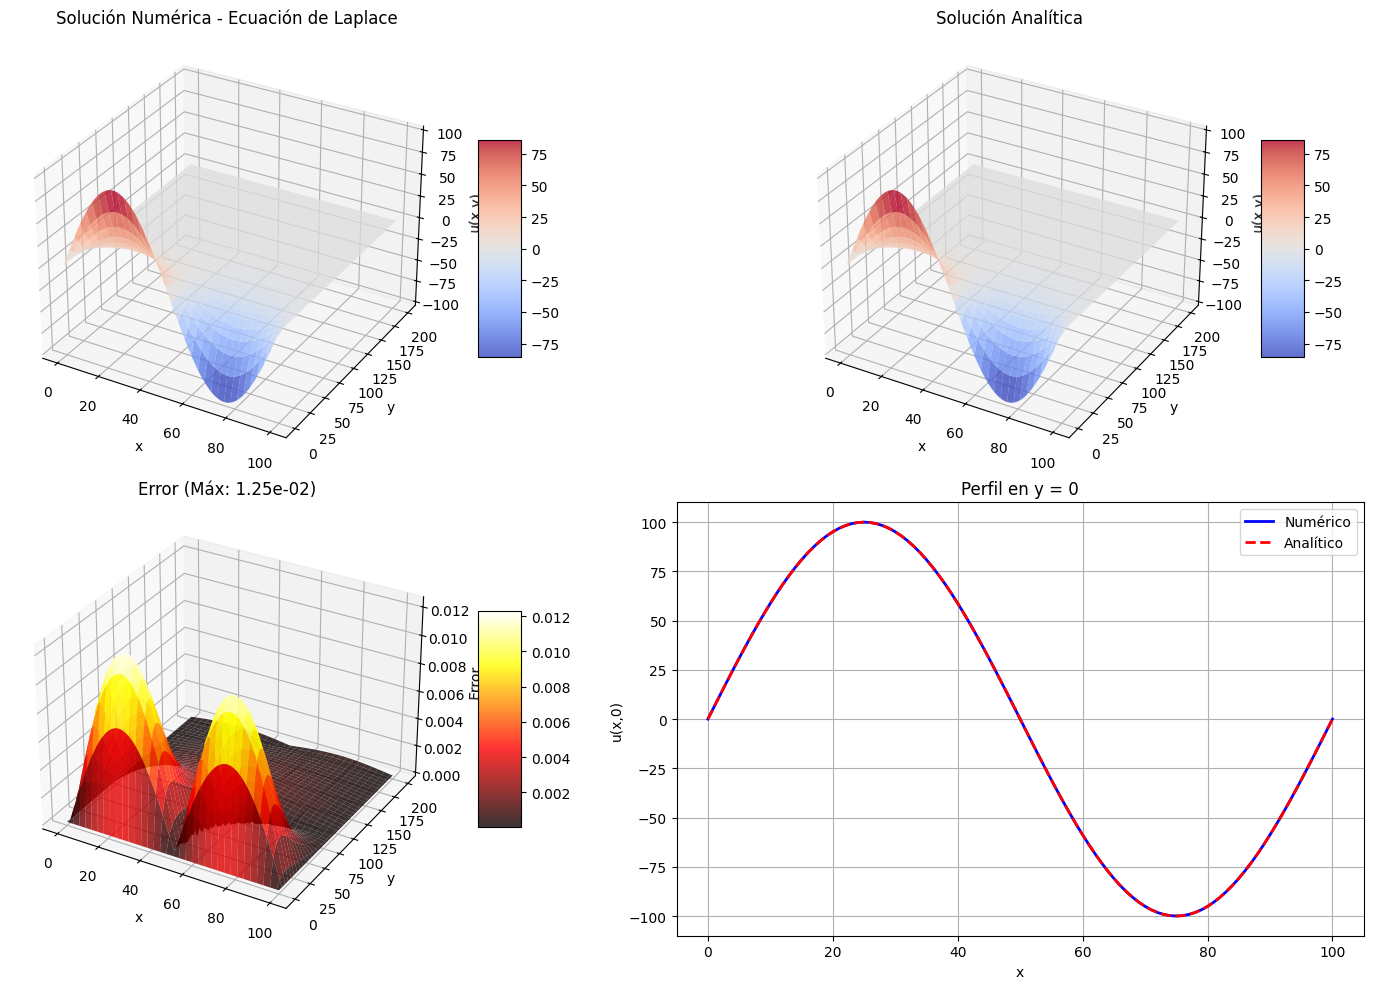


Valor en y máxima (200): máx = 0.000000
Esperado: 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parámetros del problema
L = 100  # Longitud del dominio
N = 100  # Número de puntos en x
dy = 1   # Espaciado en y (Δ = 1)
dx = L/N  # Δx = 1 también
u0 = 100  # Amplitud del potencial

# Definir el número de puntos en y (dominio semi-infinito, usaremos un valor grande)
Ny = 200  # Suficientemente grande para aproximar y → ∞

# Crear la malla
x = np.linspace(0, L, N+1)
y = np.linspace(0, Ny*dy, Ny+1)
X, Y = np.meshgrid(x, y, indexing='ij')

# Inicializar la matriz de potencial u(x,y)
u = np.zeros((N+1, Ny+1))

# Condiciones de frontera
# u(x, 0) = u0 * sin(2πx/L) * exp(-2π*0/L) = u0 * sin(2πx/L)
u[:, 0] = u0 * np.sin(2*np.pi*x/L)

# u(0, y) = 0 y u(L, y) = 0 (ya están inicializadas en cero)
# u(x, ∞) = 0 (asumimos que en y = Ny*dy es aproximadamente cero)

# Método de diferencias finitas (relajación)
max_iter = 50000
tolerance = 1e-6
max_change = 0

for iteration in range(max_iter):
    u_old = u.copy()

    # Iterar sobre puntos interiores (excluyendo fronteras)
    for i in range(1, N):  # puntos interiores en x
        for j in range(1, Ny):  # puntos interiores en y
            # Ecuación de Laplace en diferencias finitas: u_xx + u_yy = 0
            # (u_{i+1,j} - 2u_{i,j} + u_{i-1,j})/dx^2 + (u_{i,j+1} - 2u_{i,j} + u_{i,j-1})/dy^2 = 0
            # Despejando u_{i,j}:
            u[i, j] = (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1]) / 4

    # Verificar convergencia
    max_change = np.max(np.abs(u - u_old))
    if max_change < tolerance:
        print(f"Convergencia alcanzada después de {iteration + 1} iteraciones")
        break

    # Mostrar progreso cada 1000 iteraciones
    if (iteration + 1) % 1000 == 0:
        print(f"Iteración {iteration + 1}, cambio máximo: {max_change:.6f}")

# Solución analítica para verificar
def analytical_solution(x, y, L, u0):
    """Solución analítica de la ecuación de Laplace con las condiciones dadas"""
    return u0 * np.sin(2*np.pi*x/L) * np.exp(-2*np.pi*y/L)

u_analytical = analytical_solution(X, Y, L, u0)

# Calcular el error
error = np.abs(u - u_analytical)
max_error = np.max(error)
print(f"\nError máximo: {max_error:.6f}")

# Graficar resultados
fig = plt.figure(figsize=(15, 10))

# Gráfico 3D de la solución numérica
ax1 = fig.add_subplot(221, projection='3d')
surf1 = ax1.plot_surface(X, Y, u, cmap='coolwarm', alpha=0.8)
ax1.set_title('Solución Numérica - Ecuación de Laplace')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u(x,y)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# Gráfico 3D de la solución analítica
ax2 = fig.add_subplot(222, projection='3d')
surf2 = ax2.plot_surface(X, Y, u_analytical, cmap='coolwarm', alpha=0.8)
ax2.set_title('Solución Analítica')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u(x,y)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

# Gráfico de error
ax3 = fig.add_subplot(223, projection='3d')
surf3 = ax3.plot_surface(X, Y, error, cmap='hot', alpha=0.8)
ax3.set_title(f'Error (Máx: {max_error:.2e})')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('Error')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=5)

# Gráfico de perfil en y=0 (frontera)
ax4 = fig.add_subplot(224)
ax4.plot(x, u[:, 0], 'b-', linewidth=2, label='Numérico')
ax4.plot(x, u_analytical[:, 0], 'r--', linewidth=2, label='Analítico')
ax4.set_title('Perfil en y = 0')
ax4.set_xlabel('x')
ax4.set_ylabel('u(x,0)')
ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()

# Verificar condición de frontera en y → ∞
print(f"\nValor en y máxima ({y[-1]:.0f}): máx = {np.max(u[:, -1]):.6f}")
print(f"Esperado: 0")

muy bien... bonnus nota 5.0